In [2]:
using JuMP
using Gurobi          # or HiGHS, CPLEX, etc.
using CSV, DataFrames, Plots


# Unit Commitment Model

In [3]:
function build_pf_uc(pi_hat::Vector{Float64},
                     cf::Float64,
                     cstart::Float64,
                     cfixed::Float64,
                     Pmax::Float64,
                     Pmin::Float64,
                     R::Float64,
                     Mup::Int,
                     Mdown::Int,
                     y0::Int,
                     p0::Float64)

    T = length(pi_hat)

    model = Model(Gurobi.Optimizer)
    # set_silent(model)   # comment this out if you want solver output

    # Decision variables
    @variable(model, 0 <= p[1:T] <= Pmax)   # power output (MW)
    @variable(model, y[1:T], Bin)          # on/off
    @variable(model, u[1:T], Bin)          # startup
    @variable(model, w[1:T], Bin)          # shutdown

    # Objective: profit over full horizon (perfect foresight on pi_hat)
    @objective(model, Max,
        sum((pi_hat[t] - cf) * p[t] - cstart * u[t] - cfixed * y[t] for t in 1:T)
    )

    # Startup/shutdown logic
    for t in 1:T
        if t == 1
            # y1 - y0 = u1 - w1
            @constraint(model, y[1] - y0 == u[1] - w[1])
            @constraint(model, u[1] <= 1 - y0)
            @constraint(model, w[1] <= y0)
        else
            # yt - y(t-1) = ut - wt
            @constraint(model, y[t] - y[t-1] == u[t] - w[t])
            @constraint(model, u[t] <= 1 - y[t-1])
            @constraint(model, w[t] <= y[t-1])
        end
        @constraint(model, u[t] <= y[t])
        @constraint(model, w[t] <= 1 - y[t])
    end

    # Capacity limits and min stable load
    for t in 1:T
        @constraint(model, p[t] <= Pmax * y[t])
        @constraint(model, p[t] >= Pmin * y[t])
    end

    # Ramping (including from initial condition p0)
    @constraint(model,  p[1] - p0 <= R)
    @constraint(model,  p0 - p[1] <= R)
    for t in 2:T
        @constraint(model,  p[t] - p[t-1] <= R)
        @constraint(model,  p[t-1] - p[t] <= R)
    end

    # Minimum up-time: if you start at t, must stay on for at least Mup periods
    if Mup > 0
        for t in 1:(T - Mup + 1)
            @constraint(model, sum(y[k] for k in t:(t + Mup - 1)) >= Mup * u[t])
        end
    end

    # Minimum down-time: if you shut down at t, must stay off for at least Mdown periods
    if Mdown > 0
        for t in 1:(T - Mdown + 1)
            @constraint(model, sum(1 - y[k] for k in t:(t + Mdown - 1)) >= Mdown * w[t])
        end
    end

    return model, p, y, u, w
end



build_pf_uc (generic function with 1 method)

In [4]:
# -------------------------
# Example: full-year PF run
# -------------------------
# 1) Load your hourly prices (one row per hour, full year)
#    Say the CSV has a column :price in $/MWh

df = CSV.read("../clean_data/test_data_baseline.csv", DataFrame)
pi_hat = collect(df.HB_NORTH)

# 2) Set plant parameters (replace with your actual values)
cf     = 50.0        # $/MWh
cstart = 10_000.0    # $/start
cfixed = 2_000.0     # $/h
Pmax   = 171.0       # MW
Pmin   = 68.0        # MW
R      = 171.0       # MW per hour (or tighter if ramp binding)
Mup    = 4           # hours
Mdown  = 4           # hours
y0     = 0           # initially off
p0     = 0.0         # MW

model, p, y, u, w = build_pf_uc(pi_hat, cf, cstart, cfixed,
                                Pmax, Pmin, R,
                                Mup, Mdown,
                                y0, p0)

optimize!(model)

println("PF objective (total profit): ", objective_value(model))
p_opt = value.(p)
y_opt = value.(y)
u_opt = value.(u)
w_opt = value.(w)

T = length(p_opt)
t = 1:T



Set parameter Username
Set parameter LicenseID to value 2715058
Academic license - for non-commercial use only - expires 2026-09-26
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 64124 rows, 23320 columns and 174865 nonzeros
Model fingerprint: 0x2df9bade
Variable types: 5830 continuous, 17490 integer (17490 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e-02, 1e+04]
  Bounds range     [2e+02, 2e+02]
  RHS range        [1e+00, 2e+02]
Found heuristic solution: objective -0.0000000
Presolve removed 23350 rows and 5841 columns
Presolve time: 0.25s
Presolved: 40774 rows, 17479 columns, 116494 nonzeros
Variable types: 0 continuous, 17479 integer (17479 binary)

Deterministic concurrent LP optimizer: primal and dual simplex (primal and dual model)
Showing primal log only...

Root relaxation preso

1:5830

In [5]:
# Save optimization outputs to CSV
using DataFrames, CSV

# Build output arrays for costs and revenues
variable_cost = cf .* p_opt           # $/MWh * MW = $/h variable cost per period
fixed_cost = cfixed .* y_opt          # fixed cost per period when committed
startup_cost = cstart .* u_opt        # startup cost when a startup occurs
revenue = pi_hat .* p_opt             # price * dispatch
profit = revenue .- variable_cost .- fixed_cost .- startup_cost

# Build output DataFrame
df_out = DataFrame(
    t = collect(1:length(p_opt)),
    price = pi_hat,
    p = p_opt,
    y = y_opt,
    u = u_opt,
    w = w_opt,
    variable_cost = variable_cost,
    fixed_cost = fixed_cost,
    startup_cost = startup_cost,
    revenue = revenue,
    profit = profit,
)

# Ensure output directory exists (relative path)
out_path = "../opti_data/PF_schedule.csv"
CSV.write(out_path, df_out)
println("Wrote schedule to: ", out_path, " (", nrow(df_out), " rows)")


Wrote schedule to: ../opti_data/PF_schedule.csv (5830 rows)
 (5830 rows)


# Visualization

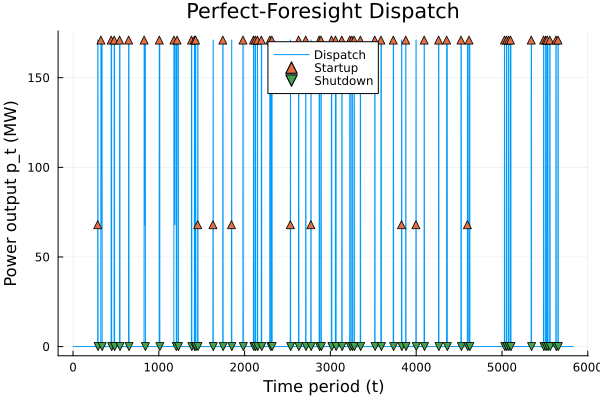

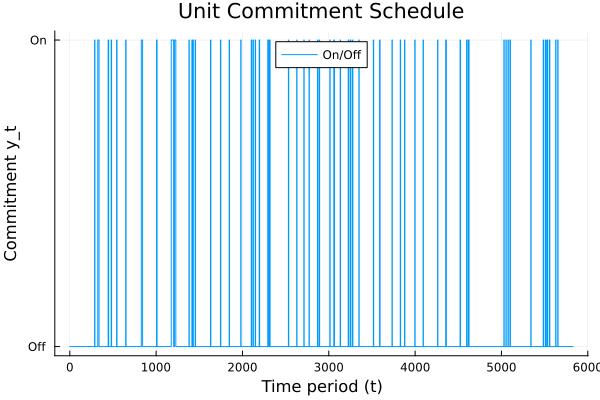

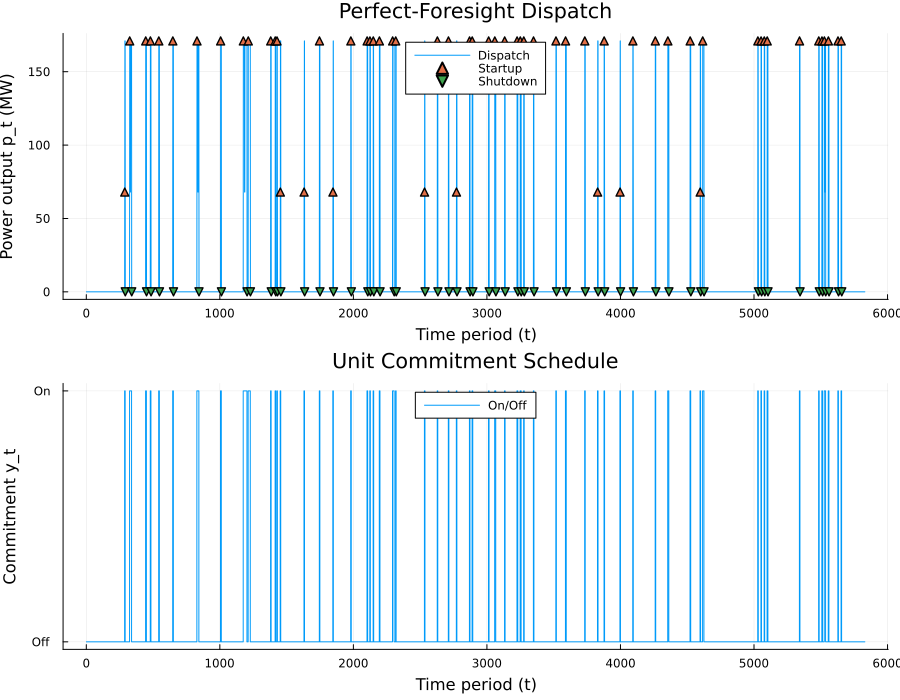

In [6]:
# Basic dispatch line
p_plot = plot(
    t, p_opt,
    xlabel = "Time period (t)",
    ylabel = "Power output p_t (MW)",
    label = "Dispatch",
    legend = :top,
    title = "Perfect-Foresight Dispatch"
)

# Mark startups (u_t = 1) and shutdowns (w_t = 1)
startup_idx   = findall(x -> x > 0.5, u_opt)
shutdown_idx  = findall(x -> x > 0.5, w_opt)

if !isempty(startup_idx)
    scatter!(
        p_plot,
        startup_idx,
        p_opt[startup_idx],
        markershape = :utriangle,
        label = "Startup",
    )
end

if !isempty(shutdown_idx)
    scatter!(
        p_plot,
        shutdown_idx,
        p_opt[shutdown_idx],
        markershape = :dtriangle,
        label = "Shutdown",
    )
end

display(p_plot)

y_plot = plot(
    t, y_opt,
    seriestype = :steppre,
    xlabel = "Time period (t)",
    ylabel = "Commitment y_t",
    yticks = ([0, 1], ["Off", "On"]),
    label = "On/Off",
    legend = :top,
    title = "Unit Commitment Schedule"
)

display(y_plot)

combined = plot(
    p_plot,
    y_plot,
    layout = (2, 1),
    size = (900, 700),
)

display(combined)


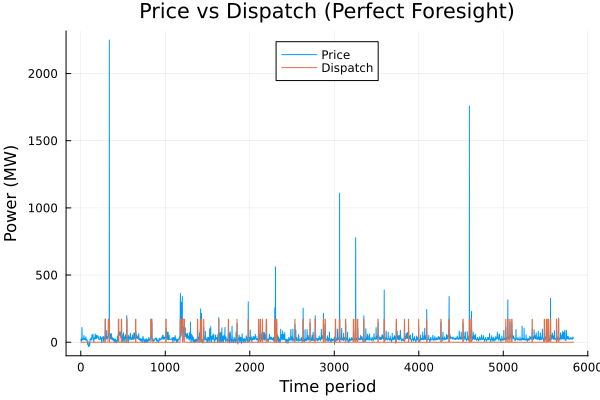

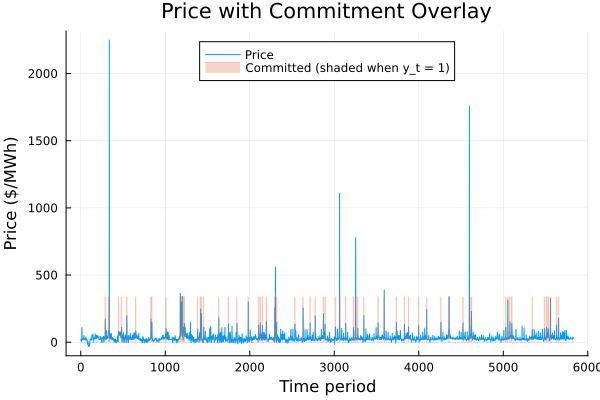

┌ Warning: Skipped yaxis arg right
└ @ Plots /Users/vkori/.julia/packages/Plots/8ZnR3/src/axes.jl:75


In [7]:
# t index
T = length(pi_hat)
t = 1:T

# 1) Price + Dispatch on twin y-axes
plt1 = plot(
    t, pi_hat,
    xlabel = "Time period",
    ylabel = "Price (\$/MWh)",
    label  = "Price",
    legend = :top,
    title  = "Price vs Dispatch (Perfect Foresight)",
)

# Add dispatch on right y-axis
plot!(
    plt1,
    t, p_opt,
    ylabel = "Power (MW)",
    label  = "Dispatch",
    yaxis  = :right,
)

display(plt1)

# 2) Price with commitment shaded (0/1 scaled to MW or as band)

# Option A: show commitment as 0/1 line under price
plt2 = plot(
    t, pi_hat,
    xlabel = "Time period",
    ylabel = "Price (\$/MWh)",
    label  = "Price",
    legend = :top,
    title  = "Price with Commitment Overlay",
)

# Scale y_opt to [0, max(pi_hat)] just for visualization band
y_band = (maximum(pi_hat) * 0.15) .* y_opt  # 15% of max price

plot!(
    plt2,
    t, y_band,
    fillrange = 0,
    seriestype = :steppre,
    alpha = 0.3,
    label = "Committed (shaded when y_t = 1)",
)

display(plt2)


# Test Unit Commitment against Actual Prices

In [8]:

function compute_profit(pi::Vector{Float64},
                        p::Vector{Float64},
                        y::Vector{Float64},
                        u::Vector{Float64};
                        cf::Float64,
                        cstart::Float64,
                        cfixed::Float64)

    T = length(pi)
    @assert length(p) == T && length(y) == T && length(u) == T "Length mismatch"

    profit = 0.0
    for t in 1:T
        margin   = (pi[t] - cf) * p[t]
        startup  = cstart * u[t]
        fixed    = cfixed * y[t]
        profit  += margin - startup - fixed
    end
    return profit
end


compute_profit (generic function with 1 method)

## Full Function with Optimization and Realization

In [9]:
# ─────────────────────────────────────────────
# Assumes you have this from before:
# build_pf_uc(pi_hat, cf, cstart, cfixed, Pmax, Pmin, R, Mup, Mdown, y0, p0)
# ─────────────────────────────────────────────

"""
run_uc_forecast_vs_actual(pi_pred, pi_real; params...)

- pi_pred: predicted prices used in optimization (length T)
- pi_real: actual realized prices (same length T)

Keyword params:
- cf, cstart, cfixed, Pmax, Pmin, R, Mup, Mdown, y0, p0

Returns:
- forecast_profit_pred_prices::Float64   # objective when solved on predicted prices
- realized_profit_actual_prices::Float64 # same schedule evaluated on actual prices
- pf_profit_actual_prices::Float64       # perfect-foresight UC using actual prices
"""
function run_uc_forecast_vs_actual(pi_pred::Vector{Float64},
                                   pi_real::Vector{Float64};
                                   cf::Float64,
                                   cstart::Float64,
                                   cfixed::Float64,
                                   Pmax::Float64,
                                   Pmin::Float64,
                                   R::Float64,
                                   Mup::Int,
                                   Mdown::Int,
                                   y0::Int,
                                   p0::Float64)

    @assert length(pi_pred) == length(pi_real) "predicted and actual price vectors must have same length"
    T = length(pi_pred)

    # 1) Optimize UC using *predicted* prices
    model_forecast, p_f, y_f, u_f, w_f = build_pf_uc(
        pi_pred, cf, cstart, cfixed,
        Pmax, Pmin, R, Mup, Mdown, y0, p0
    )
    optimize!(model_forecast)

    p_forecast = value.(p_f)
    y_forecast = value.(y_f)
    u_forecast = value.(u_f)

    forecast_profit_pred_prices = objective_value(model_forecast)

    # 2) Evaluate that schedule under *actual* prices
    realized_profit_actual_prices = compute_profit(
        pi_real,
        p_forecast,
        y_forecast,
        u_forecast;
        cf = cf,
        cstart = cstart,
        cfixed = cfixed,
    )

    # 3) Solve perfect-foresight UC using *actual* prices as the objective
    model_pf, p_pf, y_pf, u_pf, w_pf = build_pf_uc(
        pi_real, cf, cstart, cfixed,
        Pmax, Pmin, R, Mup, Mdown, y0, p0
    )
    optimize!(model_pf)
    pf_profit_actual_prices = objective_value(model_pf)

    return forecast_profit_pred_prices,
           realized_profit_actual_prices,
           pf_profit_actual_prices
end


run_uc_forecast_vs_actual

In [10]:
# LQAD q50 model
df = CSV.read("../clean_data/test_data_features_24hr.csv", DataFrame)

pi_real = collect(df.HB_NORTH)
df_LQAD_q50 = CSV.read("../price_data/lqad_q50.csv", DataFrame)

pi_LQADq50 = collect(df_LQAD_q50.price_q50)

run_uc_forecast_vs_actual(
    pi_LQADq50,
    pi_real;
    cf = 50.0,
    cstart = 10_000.0,
    cfixed = 2_000.0,
    Pmax = 171.0,
    Pmin = 68.0,
    R = 171.0,
    Mup = 4,
    Mdown = 4,
    y0 = 0,
    p0 = 0.0,
)


Set parameter Username
Set parameter LicenseID to value 2715058
Academic license - for non-commercial use only - expires 2026-09-26
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 62276 rows, 22648 columns and 169825 nonzeros
Model fingerprint: 0x998c5259
Variable types: 5662 continuous, 16986 integer (16986 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e-01, 1e+04]
  Bounds range     [2e+02, 2e+02]
  RHS range        [1e+00, 2e+02]
Found heuristic solution: objective -0.0000000
Presolve removed 22665 rows and 5668 columns
Presolve time: 0.27s
Presolved: 39611 rows, 16980 columns, 113171 nonzeros
Variable types: 0 continuous, 16980 integer (16980 binary)

Deterministic concurrent LP optimizer: primal and dual simplex (primal and dual model)
Showing primal log only...

Root relaxation preso

(45361.77580175646, 51822.28, 3.2655868e6)

In [11]:
# LQAD q95 model
df = CSV.read("../clean_data/test_data_features_24hr.csv", DataFrame)

pi_real = collect(df.HB_NORTH)
df_LQAD_q95 = CSV.read("../price_data/lqad_q95.csv", DataFrame)

pi_LQADq95 = collect(df_LQAD_q95.price_q50)     # Incorrect column name

run_uc_forecast_vs_actual(
    pi_LQADq95,
    pi_real;
    cf = 50.0,
    cstart = 10_000.0,
    cfixed = 2_000.0,
    Pmax = 171.0,
    Pmin = 68.0,
    R = 171.0,
    Mup = 4,
    Mdown = 4,
    y0 = 0,
    p0 = 0.0,
)


Set parameter Username
Set parameter LicenseID to value 2715058
Academic license - for non-commercial use only - expires 2026-09-26
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 62276 rows, 22648 columns and 169825 nonzeros
Model fingerprint: 0x640b0232
Variable types: 5662 continuous, 16986 integer (16986 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [2e-02, 1e+04]
  Bounds range     [2e+02, 2e+02]
  RHS range        [1e+00, 2e+02]
Found heuristic solution: objective -0.0000000
Presolve removed 22665 rows and 5668 columns
Presolve time: 0.24s
Presolved: 39611 rows, 16980 columns, 113171 nonzeros
Variable types: 0 continuous, 16980 integer (16980 binary)

Deterministic concurrent LP optimizer: primal and dual simplex (primal and dual model)
Showing primal log only...

Root relaxation preso

(5.9253509265923835e7, -9.86518092000002e6, 3.2655868e6)

In [13]:
# LQAD q25
df = CSV.read("../clean_data/test_data_features_24hr.csv", DataFrame)
pi_real = collect(df.HB_NORTH)
df_LQAD_q25 = CSV.read("../price_data/lqad_q25.csv", DataFrame)
pi_LQADq25 = collect(df_LQAD_q25.value)   # Corrected column name
run_uc_forecast_vs_actual(
    pi_LQADq25,
    pi_real;
    cf = 50.0,
    cstart = 10_000.0,
    cfixed = 2_000.0,
    Pmax = 171.0,
    Pmin = 68.0,
    R = 171.0,
    Mup = 4,
    Mdown = 4,
    y0 = 0,
    p0 = 0.0,
)

Set parameter Username
Set parameter LicenseID to value 2715058
Academic license - for non-commercial use only - expires 2026-09-26
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 62276 rows, 22648 columns and 169825 nonzeros
Model fingerprint: 0x647daacc
Variable types: 5662 continuous, 16986 integer (16986 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [2e+00, 1e+04]
  Bounds range     [2e+02, 2e+02]
  RHS range        [1e+00, 2e+02]
Found heuristic solution: objective -0.0000000
Presolve removed 62266 rows and 22643 columns
Presolve time: 0.15s
Presolved: 10 rows, 5 columns, 24 nonzeros
Variable types: 0 continuous, 5 integer (5 binary)

Explored 0 nodes (0 simplex iterations) in 0.16 seconds (0.30 work units)
Thread count was 10 (of 10 available processors)

Solution count 1: -0 
No other

(-0.0, 0.0, 3.2655868e6)

In [12]:
# Lag baseline
df = CSV.read("../clean_data/test_data_features_24hr.csv", DataFrame)

pi_real = collect(df.HB_NORTH)
pi_baseline = collect(df.price_lag24)
run_uc_forecast_vs_actual(
    pi_baseline,
    pi_real;
    cf = 50.0,
    cstart = 10_000.0,
    cfixed = 2_000.0,
    Pmax = 171.0,
    Pmin = 68.0,
    R = 171.0,
    Mup = 4,
    Mdown = 4,
    y0 = 0,
    p0 = 0.0,
)

Set parameter Username
Set parameter LicenseID to value 2715058
Academic license - for non-commercial use only - expires 2026-09-26
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 62276 rows, 22648 columns and 169825 nonzeros
Model fingerprint: 0x1f18d4ed
Variable types: 5662 continuous, 16986 integer (16986 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e-02, 1e+04]
  Bounds range     [2e+02, 2e+02]
  RHS range        [1e+00, 2e+02]
Found heuristic solution: objective -0.0000000
Presolve removed 22665 rows and 5668 columns
Presolve time: 0.22s
Presolved: 39611 rows, 16980 columns, 113171 nonzeros
Variable types: 0 continuous, 16980 integer (16980 binary)

Deterministic concurrent LP optimizer: primal and dual simplex (primal and dual model)
Showing primal log only...

Root relaxation preso

(3.2655868e6, -642814.4499999996, 3.2655868e6)